# Lección 7 (parte 2) - ARIMAX: ARIMA con variables exógenas

En esta segunda parte veremos cómo implementar de forma práctica un modelo ARIMAX con ayuda de las librerías StatsForecast y MLForecast.

## 1. Importación de librerías

In [1]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# Modelo de regresión <--------
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from mlforecast import MLForecast

# Modelo ARIMA con stasforecast
from statsforecast import StatsForecast
from statsforecast.models import ARIMA

RUTA = '/Users/miguel/Library/CloudStorage/GoogleDrive-miguel@codificandobits.com/My Drive/02-CODIFICANDOBITS.COM/04-Academia/01-Cursos/45-2026-03-ARIMA/data/'

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 4)

## 2. El set de datos y el problema a resolver

Usaremos el set de datos "ventas_arimax.csv" que contiene el registro histórico de ventas de una cierta categoría de productos durante el último año.

Además de esto, contamos con datos de dos variables exógenas para el mismo periodo de tiempo:
- Si hubo o no promociones (1 o 0)
- Si se trató de un evento especial o no (1 o 0)

Así que el problema a resolver será:

> Construir un modelo ARIMAX para pronosticar las ventas con un horizonte de 7 días, que incorpore no sólo el comportamiento histórico de la Serie sino también las variables exógenas

Comencemos leyendo el set de datos:

In [2]:
# Leer dataset
df = pd.read_csv(RUTA + 'ventas_arimax.csv', parse_dates=['ds'])
df

,unique_id,ds,promociones,eventos,y
0,productos_C,2025-03-01,0,0,19
1,productos_C,2025-03-02,0,0,18
2,productos_C,2025-03-03,0,0,18
3,productos_C,2025-03-04,0,0,22
4,productos_C,2025-03-05,0,0,19
...,...,...,...,...,...
360,productos_C,2026-02-24,0,0,20
361,productos_C,2026-02-25,0,0,18
362,productos_C,2026-02-26,0,0,21
363,productos_C,2026-02-27,0,1,27


Y veamos el comportamiento en el tiempo tanto de la Serie como de las variables exógenas:

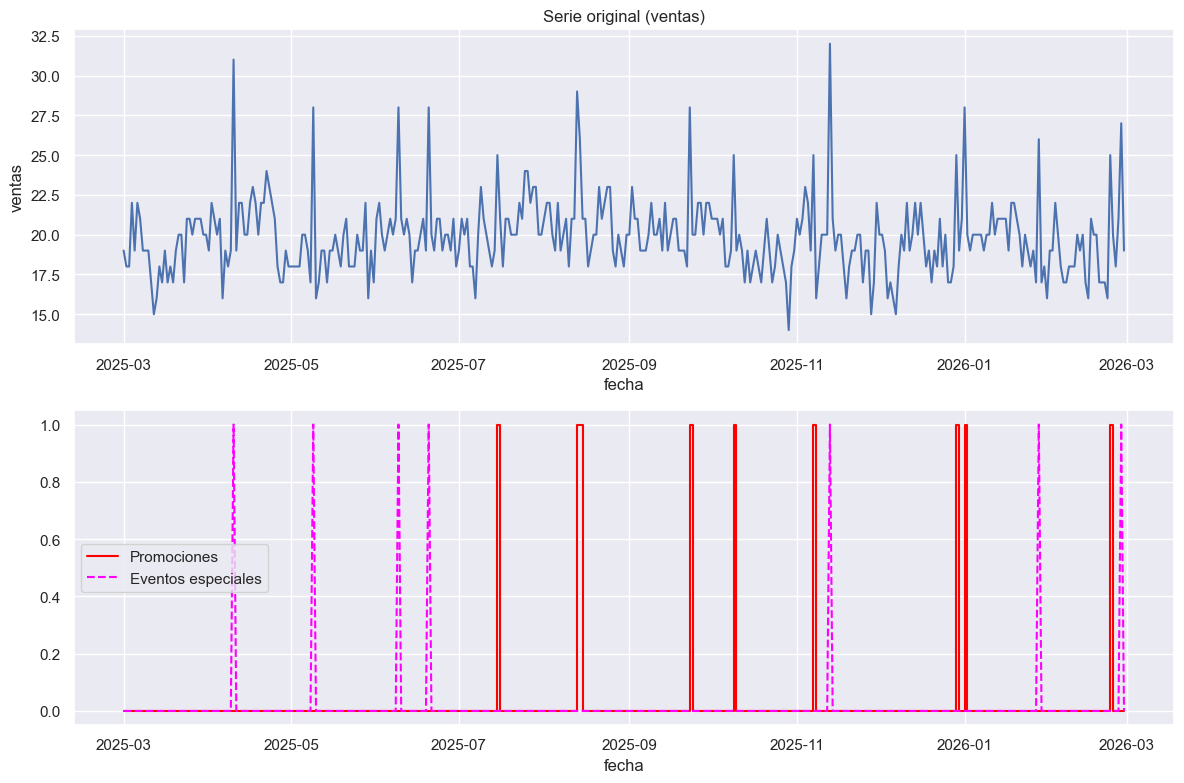

In [3]:
# Graficar serie y variables exógenas
fig, axs = plt.subplots(2,1,figsize=(12,8))

# Serie
sns.lineplot(df, x="ds", y="y", ax=axs[0])
axs[0].set_title('Serie original (ventas)')
axs[0].set_xlabel('fecha')
axs[0].set_ylabel('ventas')

# Variables exógenas
axs[1].plot(df["ds"], df["promociones"], label="Promociones", drawstyle="steps-post", color='red')
axs[1].plot(df["ds"], df["eventos"], label="Eventos especiales", linestyle="--", color='magenta')
axs[1].set_xlabel('fecha')
axs[1].legend()

plt.tight_layout();

## 3. Estimación de los parámetros del modelo ARIMAX

Esta es la fase que diferencia esta implementación con respecto a todas las demás que hemos visto en este curso. Estas fases se pueden resumir en los siguientes pasos:

1. Crear el set de entrenamiento y prueba
2. Ajustar un modelo de regresión **sobre las variables exógenas**
3. Calcular los residuales del modelo obtenido en (2)
4. Definir los parámetros del modelo ARIMA que se construirá **sobre los residuales obtenidos en (3)**
5. Habiendo definido los parámetros del modelo ARIMA (4), entrenar y validar el modelo ARIMAX
6. Generar pronósticos con el modelo obtenido en (5)

Veamos como implementar cada una de estas fases.

### 3.1. Sets de entrenamiento y prueba

El set de entrenamiento tendrá 358 registros y el set de prueba serán los 7 últimos días:

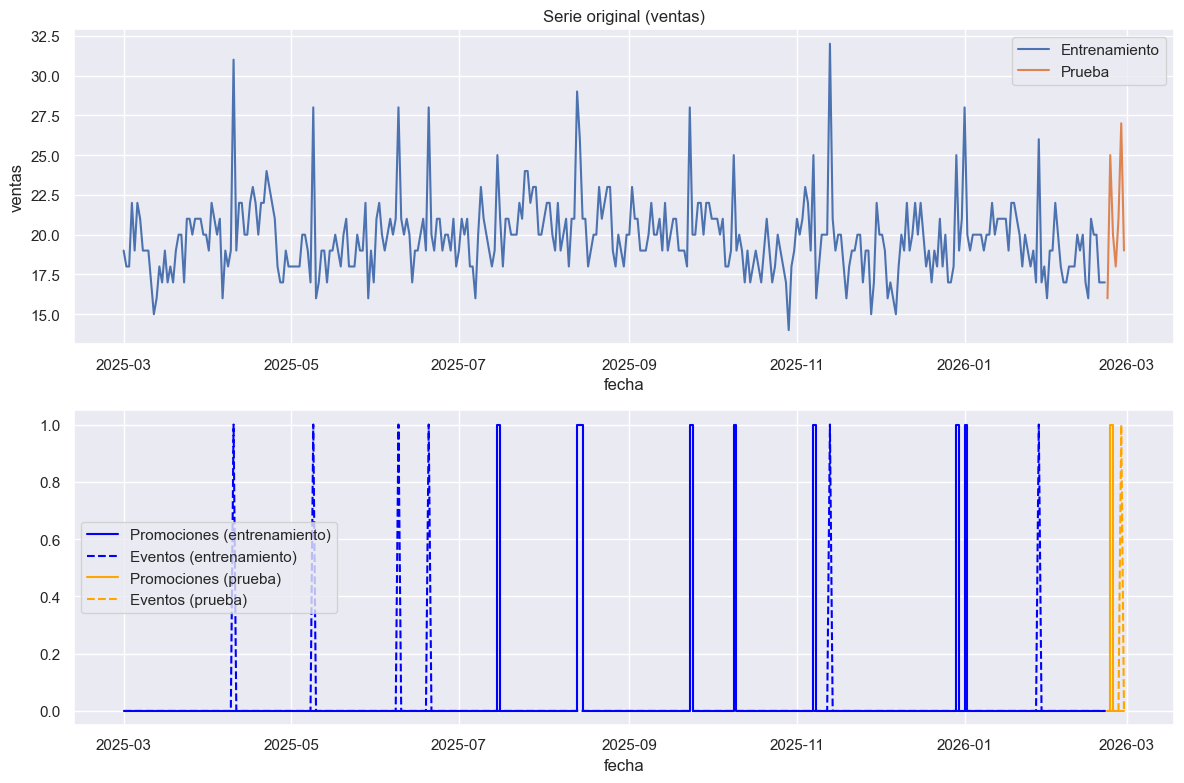

In [4]:
# Entrenamiento y prueba
df_tr = df[:358]
df_ts = df[358:] # Últimos 7 días de prueba

# Graficar
fig, axs = plt.subplots(2,1,figsize=(12,8))

# Serie
sns.lineplot(df_tr, x="ds", y="y", ax=axs[0], label='Entrenamiento')
sns.lineplot(df_ts, x="ds", y="y", ax=axs[0], label='Prueba')
axs[0].set_title('Serie original (ventas)')
axs[0].set_xlabel('fecha')
axs[0].set_ylabel('ventas')

# Variables exógenas
axs[1].plot(df_tr["ds"], df_tr["promociones"], label="Promociones (entrenamiento)", color='blue', drawstyle="steps-post")
axs[1].plot(df_tr["ds"], df_tr["eventos"], label="Eventos (entrenamiento)", color='blue', linestyle='--')

axs[1].plot(df_ts["ds"], df_ts["promociones"], label="Promociones (prueba)", color='orange', drawstyle="steps-post")
axs[1].plot(df_ts["ds"], df_ts["eventos"], label="Eventos (prueba)", color='orange', linestyle='--')

axs[1].set_xlabel('fecha')
axs[1].legend()

plt.tight_layout();

### 3.2. Modelo de regresión sobre las variables exógenas

Este es el primer paso para poder determinar posteriormente los parámetros ARIMA de este modelo.

Acá usaremos lo aprendido en la lección 9 del curso "Pronósticos de Series de Tiempo con Regresión", así que reutilizaremos varias de las funciones allí implementadas.

Comencemos determinando si hay correlación entre las ventas y las variables exógenas:

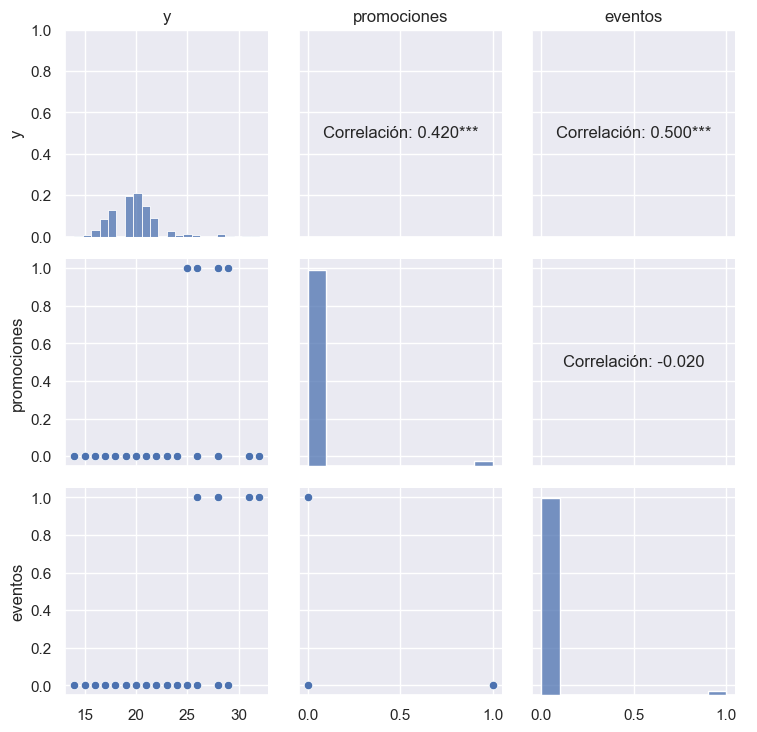

In [5]:
# Función para calcular y dibujar el nivel de correlación entre pares de variables (código tomado de la lección 9
# del curso de Pronósticos con Regresión)
def correlacion(x, y, **kws):
    # Calcular índice de correlación y valor p
    r, p = pearsonr(x, y)
    
    # Extraer axes y añadir anotación *** si el valor p es significativo
    ax = plt.gca()
    ax.annotate(f"Correlación: {r:.3f}{'***' if p < 0.05 else ''}",
               xy=(0.5, 0.5),
               xycoords = "axes fraction",
               ha = "center",
               va = "center",
    )
    
# Extraer columnas a comparar
df_plot = df_tr[["y", "promociones", "eventos"]].copy()

# Gráfico tipo Pairgrid: debajo de la diagonal -> gráficos de dispersión,
# encima de la diagonal -> Niveles de correlación
pg = sns.PairGrid(df_plot)
pg.map_diag(sns.histplot)
pg.map_upper(correlacion)
pg.map_lower(sns.scatterplot)
pg.add_legend()

# Remover etiquetas eje x
pg.set(xlabel="")

# Mover etiquetas eje "y" arriba
for i, col in enumerate(df_plot.columns):
    pg.axes[0,i].set_title(col)

Aunque el nivel de correlación no es alto (0.420 y 0.5), como vimos en esa lección 9 esto se debe a que buena parte de los valores de las variables exógenas son iguales a 0. Pero esto no nos impide implementar un modelo de regresión lineal.

Ahora entrenamos el modelo de Regresión Lineal y obtenemos las predicciones in-sample (necesarias para obtener los residuales):

In [6]:
# Regresión sobre variables exógenas (lección 9 curso Pronósticos con Regresión)

# Instancia del modelo
mlf = MLForecast(
    models=[LinearRegression()],
    freq = 'd'
)

# Entrenamiento
mlf.fit(df = df_tr,
        fitted = True, # Para que genere predicciones in-sample
       )

# Predicciones in sample
preds_is = mlf.forecast_fitted_values()
preds_is

,unique_id,ds,y,LinearRegression
0,productos_C,2025-03-01,19.0,19.526163
1,productos_C,2025-03-02,18.0,19.526163
2,productos_C,2025-03-03,18.0,19.526163
3,productos_C,2025-03-04,22.0,19.526163
4,productos_C,2025-03-05,19.0,19.526163
...,...,...,...,...
353,productos_C,2026-02-17,20.0,19.526163
354,productos_C,2026-02-18,20.0,19.526163
355,productos_C,2026-02-19,17.0,19.526163
356,productos_C,2026-02-20,17.0,19.526163


Podemos graficar la Serie original y las predicciones in-sample:

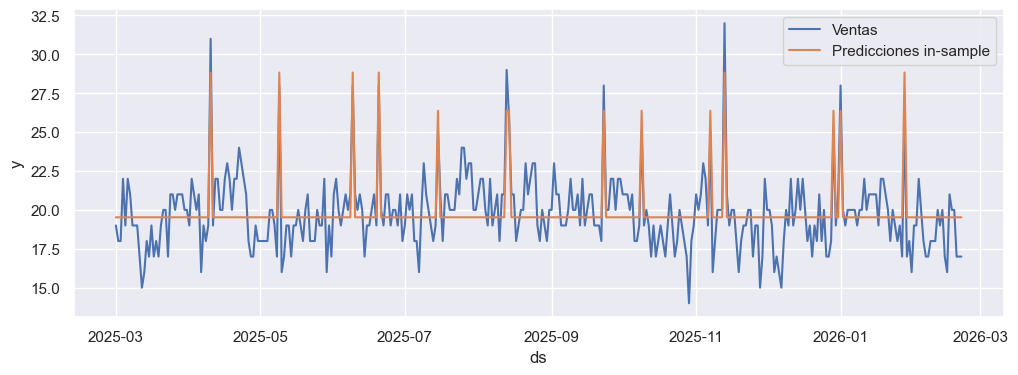

In [7]:
# Gráfico y vs. regresión variables exógenas
sns.lineplot(preds_is, x="ds", y="y", label='Ventas')
sns.lineplot(preds_is, x="ds", y="LinearRegression", label='Predicciones in-sample');

Vemos que este modelo captura una parte del comportamiento de la Serie. Lo que no logra capturar será modelado por ARIMA.

### 3.3. Residuales del modelo de Regresión

Estos residuales serán el insumo del modelo ARIMA:

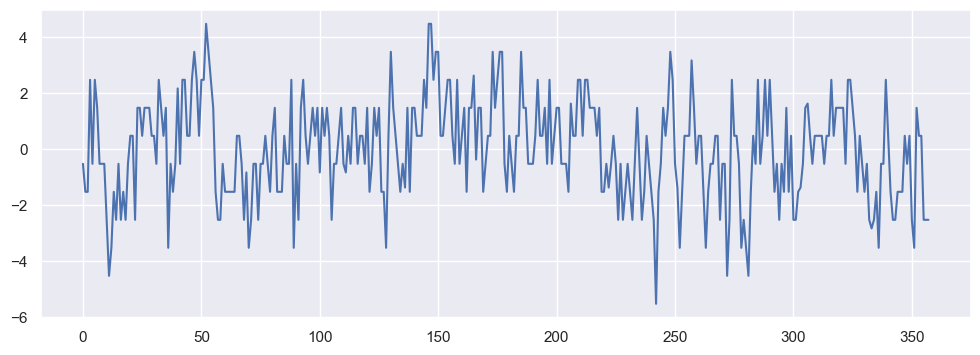

In [8]:
# Calcular residuales
res = preds_is["y"] - preds_is["LinearRegression"]
sns.lineplot(res);

### 3.4. Parámetros del modelo ARIMA construido a partir de los residuales

En esta parte llevamos a cabo el mismo procedimiento que vimos en lecciones anteriores para determinar los parámetros *p,d,q* del modelo ARIMA.

Lo importante a tener en cuenta acá es que **el modelo ARIMA se construye a partir de los residuales del modelo de Regresión, NO a partir de la Serie original**.

Comencemos reutilizando la función "prueba_diferenciacion":

In [9]:
# Sobre los residuales anteriores se estiman los parámetros ARIMA
# La misma función usada en la lección 5
def prueba_diferenciacion(serie, d, titulo):
    # Eliminar posibles NaN de la serie
    serie = serie.dropna()
    
    # Diferenciar (si d!=0)
    if d != 0:
        for _ in range(d):
            serie = serie.diff()

    
    # Aplicar prueba y mostrar resultado
    resultado = adfuller(serie.dropna())
    pval = resultado[1]
    
    if pval < 0.05:
        # Se rechaza la hipótesis nula: la serie es estacionaria
        print(f'La serie es estacionaria porque p = {pval:.2f} < 0.05. NO se requiere diferenciación')
    else:
        # Se acepta la hipótesis nula: la serie es NO estacionaria
        print(f'La serie NO es estacionaria porque p = {pval:.2f} >= 0.05. Se requiere diferenciación')
        
    # Graficar
    fig, ax = plt.subplots(1,1,figsize=(12,4))
    plt.plot(range(1,len(serie)+1), serie)
    plt.hlines(serie.mean(), xmin=1, xmax=len(serie)+1, color='red', linestyle='--');
    ax.set_title(titulo)

Apliquemos esta prueba a los residuales originales (d=0):

La serie es estacionaria porque p = 0.00 < 0.05. NO se requiere diferenciación


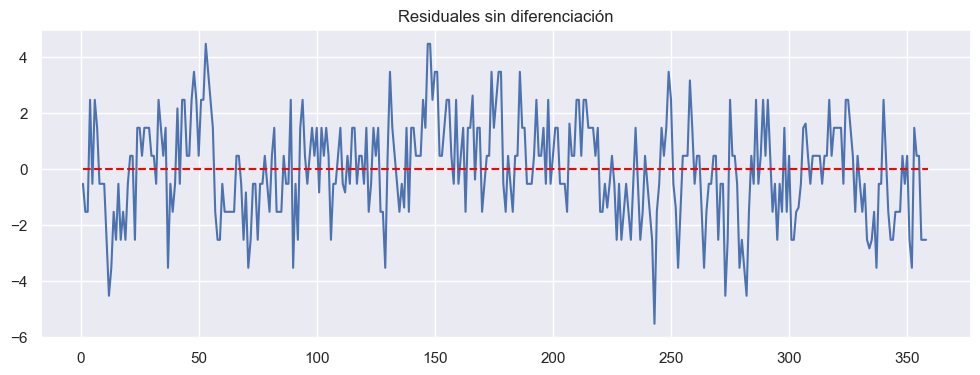

In [10]:
# Residuales sin diferenciación
prueba_diferenciacion(res, d=0, titulo='Residuales sin diferenciación');

¡La serie ya es estacionaria, así que d=0!

Veamos ahora la ACF y la PACF:

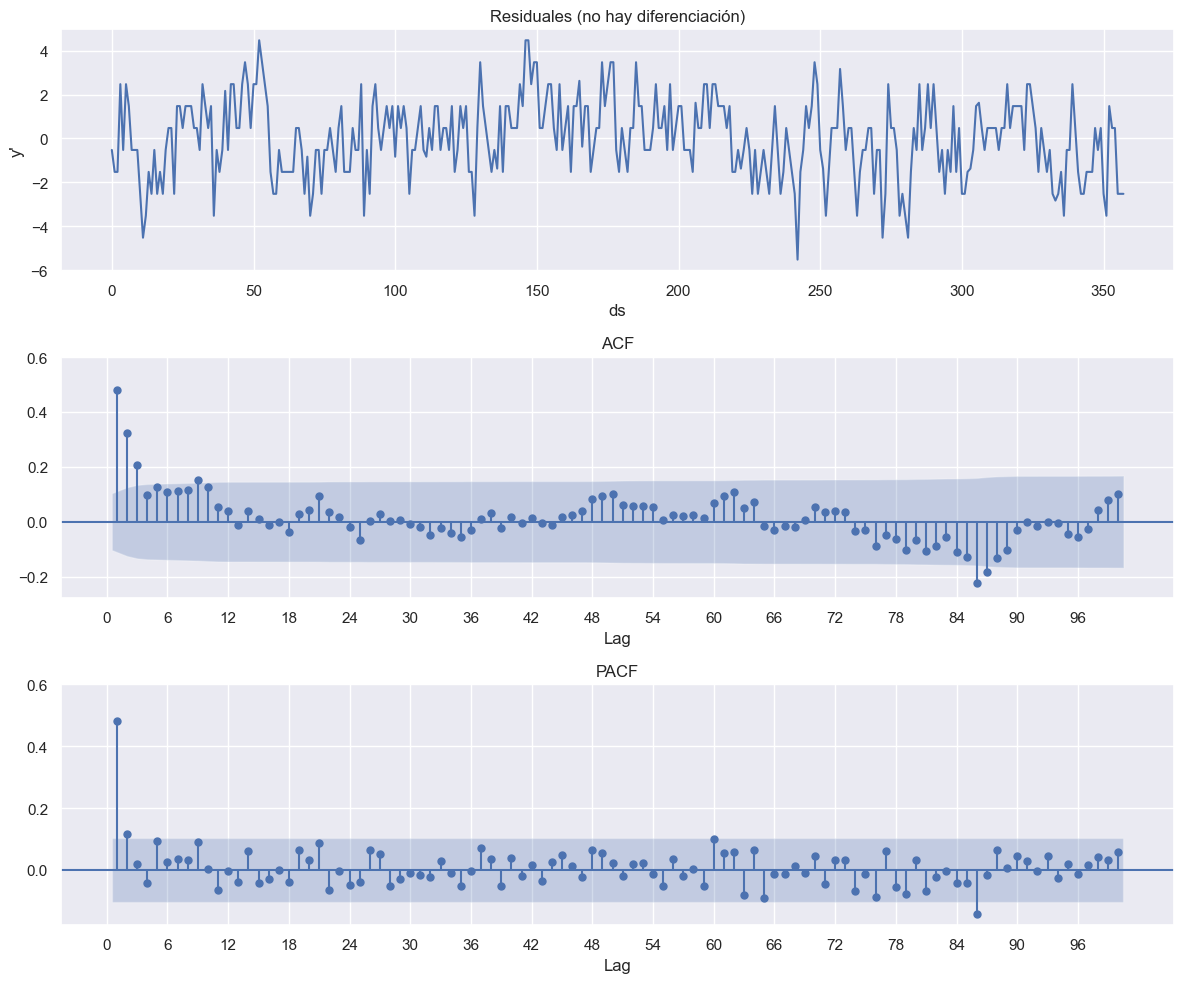

In [11]:
# ACF y PACF sobre los residuales con d=0

# No calculamos ninguna diferenciación
df_dif1 = res.copy()

# Dibujar serie diferenciada, función de autocorrelación y PACF
fig, axs = plt.subplots(3,1,figsize=(12,10))

sns.lineplot(df_dif1[:], ax=axs[0])
axs[0].set_xlabel('ds')
axs[0].set_ylabel("y'")
axs[0].set_title('Residuales (no hay diferenciación)')

LAGS = 100
plot_acf(df_dif1,
         alpha=0.05, # Intervalo de confianza del 95%
         lags=LAGS,
         zero=False,
         auto_ylims=True,
         ax=axs[1])
axs[1].set_xlabel('Lag')
axs[1].set_xticks(range(0,LAGS+1))
axs[1].set_title('ACF')
axs[1].set_xticks(range(0, LAGS + 1, 6))
axs[1].grid(True)

plot_pacf(df_dif1,
          lags=LAGS,
          zero=False,
          auto_ylims=True,
          ax=axs[2])
axs[2].set_xlabel('Lag')
axs[2].set_xticks(range(0,LAGS+1))
axs[2].set_title('PACF')
axs[2].set_xticks(range(0, LAGS + 1, 6))
axs[2].grid(True)

plt.tight_layout()


Podemos ver que:

- *q = 3*
- *p* podría ser 1 o 2. Para simplificar las cosas asumiremos *p=1* (sin embargo, se sugiere realizar ajuste de hiper-parámetros para determinar si *p=1* o *p=2*)

### 3.5. Entrenar modelo ARIMAX

Ahora usamos los parámetros obtenidos para crear la instancia de un modelo ARIMA (aún no incluiremos las variables exógenas):

In [12]:
# ARIMA(1,0,3)
models = [ARIMA(order=(1, 0, 3), alias='ARIMAX(1,0,3)')]

# Y creamos la instancia del modelo
sf = StatsForecast(models=models, freq='d')

Y acá viene lo clave. Al entrenarlo (usando "fit()") agregamos las variables exógenas:

In [13]:
df_tr

,unique_id,ds,promociones,eventos,y
0,productos_C,2025-03-01,0,0,19
1,productos_C,2025-03-02,0,0,18
2,productos_C,2025-03-03,0,0,18
3,productos_C,2025-03-04,0,0,22
4,productos_C,2025-03-05,0,0,19
...,...,...,...,...,...
353,productos_C,2026-02-17,0,0,20
354,productos_C,2026-02-18,0,0,20
355,productos_C,2026-02-19,0,0,17
356,productos_C,2026-02-20,0,0,17


In [14]:
sf.fit(df=df_tr)

StatsForecast(models=[ARIMAX(1,0,3)])

¡Ya tenemos un modelo ARIMAX!

De manera explícita no hemos definido las variables exógenas. Sin embargo, estas son las columnas "promociones" y "eventos" en el set de entrenamiento.

Así, cuando usamos "fit()", StatsForecast determina que las columnas diferentes de "ds" y "y" son las columnas con variables exógenas y entrena el modelo incluyendo estas variables.

Esto lo podemos verificar de dos formas.

Si intentamos generar predicciones aparecerá un error indicándonos que no hemos incluido las variables exógenas como argumento para la predicción:

In [15]:
# Si intentamos pronosticar aparecerá un error
sf.predict(h=7)

ValueError: Models require the following exogenous features ['promociones', 'eventos'] for the forecasting step. Please provide them through `X_df`.

O podemos acceder a los parámetros del modelo entrenado y verificar que además de los parámetros AR y MA, tendremos parámetros asociados al modelo de Regresión:

In [16]:
# Acceder a los parámetros del modelo
mod_arimax = sf.fitted_[0, 0]
mod_arimax_params = mod_arimax.model_

print("Parámetros del modelo:", mod_arimax_params.get('coef'))

Parámetros del modelo: {'ar1': -0.1585791999359217, 'ma1': 0.5965719846796542, 'ma2': 0.35927850479987605, 'ma3': 0.21822484107833506, 'intercept': 19.5112777823011, 'ex_1': 6.843040768998291, 'ex_2': 9.76611049075833}


Así que ya hemos construido nuestro modelo ARIMAX.

Se sugiere además aplicar validación cruzada para medir el desempeño del modelo entrenado (no lo haremos en esta parte).

### 3.6. Generar pronósticos con el modelo entrenado

Comenzaremos tomando el set de entrenamiento y generando pronósticos a 7 días usando el método "forecast". Para poder hacerlo **es necesario agregar las variables exógenas futuras** (es decir las de los próximos 7 días).

Comencemos entonces creando este DataFrame de variables exógenas futuras:

In [17]:
X_df = df_ts.drop(columns=["y"]) # El set de prueba sin la columna "y"
X_df

,unique_id,ds,promociones,eventos
358,productos_C,2026-02-22,0,0
359,productos_C,2026-02-23,1,0
360,productos_C,2026-02-24,0,0
361,productos_C,2026-02-25,0,0
362,productos_C,2026-02-26,0,0
363,productos_C,2026-02-27,0,1
364,productos_C,2026-02-28,0,0


Y ahora sí usamos el método "forecast":

In [20]:
fc = sf.forecast(df=df_tr, X_df = X_df, h=7, level=[90])
fc

,unique_id,ds,"ARIMAX(1,0,3)","ARIMAX(1,0,3)-lo-90","ARIMAX(1,0,3)-hi-90"
0,productos_C,2026-02-22,18.188587,15.639923,20.737249
1,productos_C,2026-02-23,25.931135,23.148726,28.713545
2,productos_C,2026-02-24,19.332098,16.453310,22.210884
3,productos_C,2026-02-25,19.539692,16.627617,22.451767
4,productos_C,2026-02-26,19.506771,16.593864,22.419680
5,productos_C,2026-02-27,29.278103,26.365175,32.191032
6,productos_C,2026-02-28,19.511164,16.598236,22.424093


Veamos cómo se comparan estos pronósticos con los datos de prueba reales:

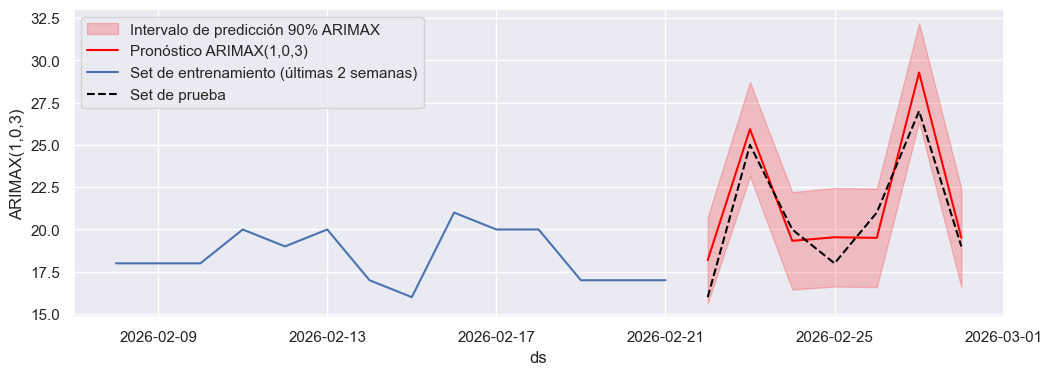

In [21]:
# Graficar
fig, ax = plt.subplots()

# ARIMAX: pronóstico puntual e intervalo de predicción
plt.fill_between(x=fc["ds"],
                 y1 = fc['ARIMAX(1,0,3)-lo-90'],
                 y2 = fc['ARIMAX(1,0,3)-hi-90'],
                 color = 'red',
                 alpha = 0.2,
                 label = 'Intervalo de predicción 90% ARIMAX');
sns.lineplot(fc, x="ds", y="ARIMAX(1,0,3)", color='red', label='Pronóstico ARIMAX(1,0,3)')

# Graficar últimas 2 semanas del set de entrenamiento así como el set de prueba original
sns.lineplot(df_tr[-14:], x="ds", y="y", label='Set de entrenamiento (últimas 2 semanas)')
sns.lineplot(df_ts, x="ds", y="y", label='Set de prueba', color='black', linestyle='--');

¡El modelo captura bastante bien el comportamiento de la Serie, teniendo en cuenta que:

- Tendremos una promoción el 2026-02-03
- Y un evento especial el 2026-02-07

El anterior ejemplo nos permitió ver cómo se comparan las predicciones con los datos de prueba conocidos.

Pero ¿qué pasa si queremos hacer un pronóstico totalmente nuevo?. En este caso seguimos estos pasos:

1. Creamos la instancia del modelo
2. Creamos un DataFrame **futuro** con las variables exógenas
3. Generamos el pronóstico introduciendo al modelo **la totalidad de los datos** y **las variables exógenas futuras**

Veamos esto paso a paso:

In [22]:
df

,unique_id,ds,promociones,eventos,y
0,productos_C,2025-03-01,0,0,19
1,productos_C,2025-03-02,0,0,18
2,productos_C,2025-03-03,0,0,18
3,productos_C,2025-03-04,0,0,22
4,productos_C,2025-03-05,0,0,19
...,...,...,...,...,...
360,productos_C,2026-02-24,0,0,20
361,productos_C,2026-02-25,0,0,18
362,productos_C,2026-02-26,0,0,21
363,productos_C,2026-02-27,0,1,27


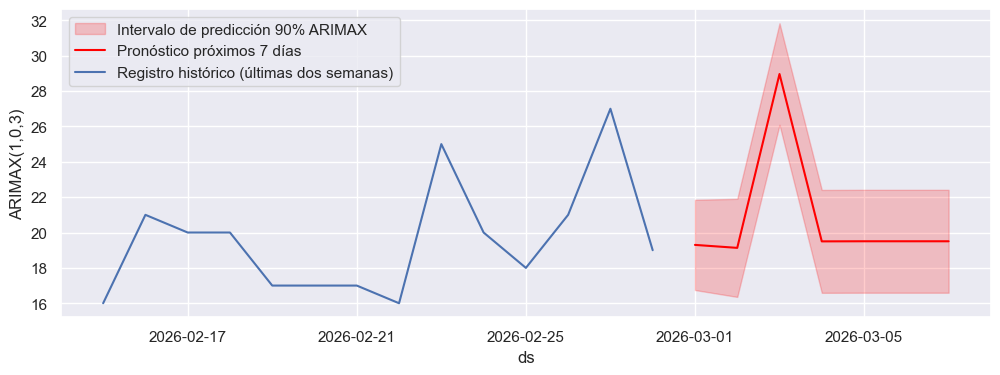

In [25]:
# Un nuevo pronóstico


# Instancia del modelo
models = [ARIMA(order=(1, 0, 3), alias='ARIMAX(1,0,3)')]
sf = StatsForecast(models=models, freq='d')

# Crear dataframe FUTURO de variables exógenas
h = 7
fechas_futuras = pd.date_range(start=df['ds'].max() + pd.Timedelta(days=1), periods=h, freq='d')
X_df = pd.DataFrame({
    'unique_id': df['unique_id'].iloc[0], # El mismo unique_id del set de entrenamiento
    'ds': fechas_futuras,
    'promociones': [0, 0, 0, 0, 0, 0, 0], # Supondremos que en el día 6 habrá una promoción
    'eventos': [0, 0, 1, 0, 0, 0, 0]      # No habrá eventos especiales en los próximos 7 días
})

# Pronosticar y graficar
fc = sf.forecast(df=df, X_df = X_df, h=7, level=[90])

fig, ax = plt.subplots()

plt.fill_between(x=fc["ds"],
                 y1 = fc['ARIMAX(1,0,3)-lo-90'],
                 y2 = fc['ARIMAX(1,0,3)-hi-90'],
                 color = 'red',
                 alpha = 0.2,
                 label = 'Intervalo de predicción 90% ARIMAX');
sns.lineplot(fc, x="ds", y="ARIMAX(1,0,3)", color='red', label='Pronóstico próximos 7 días')

sns.lineplot(df[-14:], x="ds", y="y", label='Registro histórico (últimas dos semanas)');

Y vemos que el modelo pronostica un pico de ventas precisamente en el día 6.